<a href="https://colab.research.google.com/github/siinwook/Deep-Learning-from-Scratch/blob/main/ch06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install import_ipynb
import sys, import_ipynb

from google.colab import drive
drive.mount('/content/drive')

%cd "__path__"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SGD

In [ ]:
class SGD:
  def __init__(self, lr=0.01):
    self.lr = lr

  def update(self, params, grads):
    for key in params.keys():
      params[key] -= self.lr * grads[key]

Momentum

In [ ]:
class Momentum:
  def __init__(self, lr=0.01, momentum=0.9):
    self.lr = lr
    self.momentum=momentum
    self.v = None #save original velocity

  def update(self, params, grads):
    if self.v is None: #initial v
      self.v={}
      for key, val in params.items():
        self.v[key]=np.zeros_like(val)

    for key in params.keys():
      self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
      params[key] += self.v[key]

AdaGrad

In [ ]:
class AdaGrad:
  def __init__(self, lr=0.01):
    self.lr = lr
    self.h = None

  def update(self, params, grads):
    if self.h is None:
      self.h = {}
      for key,val in params.items():
        self.h[key] = np.zeros_like(val)

    for key in params.keys():
      self.h[key] += grads[key] * grads[key] #learning rate decay
      params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

Adam

In [ ]:
class Adam:
  def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
    self.lr = lr
    self.m = None #momentum
    self.v = None #learning rate decay(each params)
    self.iter = 0
    self.beta1 = beta1
    self.beta2 = beta2

  def update(self, params, grads):
    if self.m is None:
      self.m = {}
      self.v = {}
      for key,val in params.items():
        self.m[key] = np.zeros_like(val)
        self.v[key] = np.zeros_like(val)

    self.iter+=1
    lr_t = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter) #learning rate decay(all params)

    for key in params.keys():
      self.m[key] += (1.0 - self.beta1) * (grads[key] - self.m[key])
      self.v[key] += (1.0 - self.beta2) * (grads[key]**2 - self.v[key])

      params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

optimizer compare

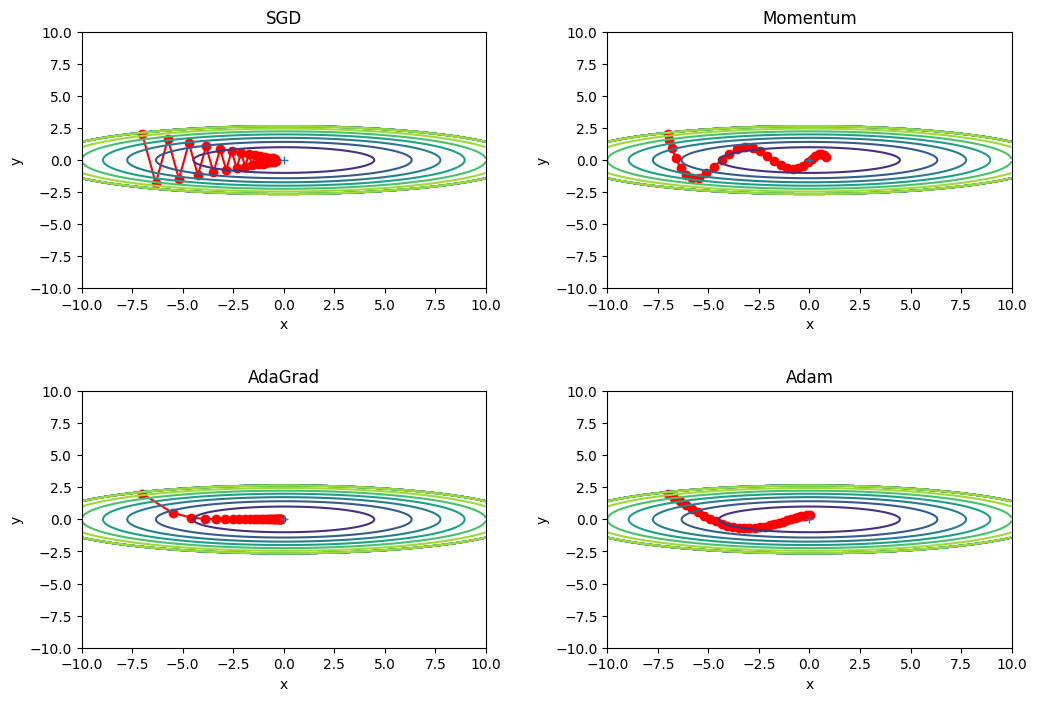

In [ ]:
from collections import OrderedDict

def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

plt.figure(figsize=(12, 8))

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]

    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])

        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)


    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)

    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0

    # 그래프 그리기
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

distibution of activation value flowing through 5-layers depending on weight initialization(S curve)

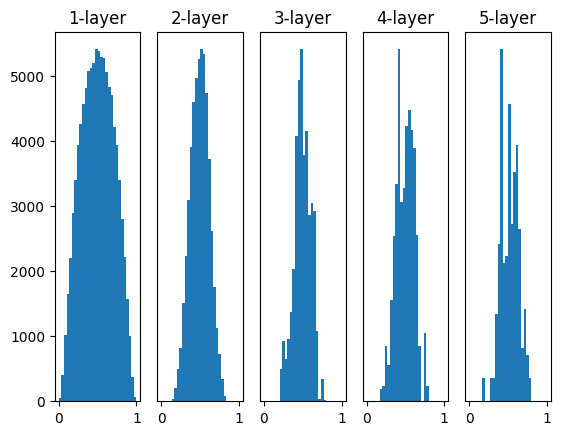

In [ ]:
from functions import sigmoid

x = np.random.randn(1000,100)
node_num = 100
hidden_layer_size = 5
activations = {}

#sigma of initial weight distribution
#sigma = 1
#sigma = 0.01
sigma = 1.0 / np.sqrt(node_num) # Xavier initialization

for i in range(hidden_layer_size):
  if i!=0:
    x = activations[i-1]

  w = np.random.randn(node_num,node_num) * sigma
  activations[i] = sigmoid(np.dot(x,w))

for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

distibution of activation value flowing through 5-layers depending on weight initialization(ReLU)

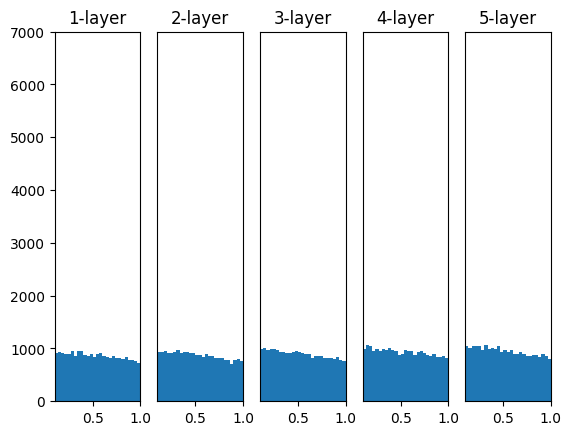

In [ ]:
from functions import relu

x = np.random.randn(1000,100)
node_num = 100
hidden_layer_size = 5
activations = {}

#sigma of initial weight distribution
#sigma = 1
#sigma = 0.01
sigma = np.sqrt(2.0 / node_num) # He initialization

for i in range(hidden_layer_size):
  if i!=0:
    x = activations[i-1]

  w = np.random.randn(node_num,node_num) * sigma
  activations[i] = relu(np.dot(x,w))

for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    plt.xlim(0.1, 1)
    plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

Drop out

In [ ]:
class Dropout:
  def __init__(self,dropout_ratio = 0.5):
    self.dropout_ratio = dropout_ratio
    self.mask = None

  def forward(self,x, train_flg=True):
    if train_flg:
      self.mask = np.random.rand(*x.shape) > self.dropout_ratio
      return x * self.mask
    else:
      return x * (1.0 - self.dropout_ratio)

  def backward(self, dout):
    return dout * self.mask

Batch normalization

In [ ]:
class BatchNormalization:
  def __init__(self,gamma, beta, train_flg=True, momentum=0.9, running_mean=None, running_var = None):
    self.input_shape = None
    self.gamma = gamma
    self.beta = beta
    self.momentum = momentum

    self.running_mean = running_mean
    self.running_var = running_var

    self.batch_size = None
    self.xc = None
    self.xn = None
    self.std = None
    self.dgamma = None
    self.dbeta = None

  def forward(self, x, train_flg):
    self.input_shape = x.shape
    if x.ndim!=2: #for CNN
      N,C,H,W = x.shape
      x = x.reshape(N,-1)

    out = self.__forward(x,train_flg)
    return out.reshape(*self.input_shape)

  def __forward(self, x, train_flg=True):
    if self.running_mean is None:
      N,D = x.shape
      self.running_mean = np.zeros_like(D)
      self.running_var = np.zeros_like(D)

    if train_flg:
      mu = x.mean(axis=0)
      xc = x - mu
      var = np.mean(xc**2,axis=0)
      std = np.sqrt(var+1e-7)
      xn = xc / std

      self.batch_size = x.shape[0]
      self.xc = xc
      self.xn = xn
      self.std = std
      self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
      self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
    else:
      xc = x - self.running_mean
      xn = xc / np.sqrt(self.running_var + 1e-7)

    out = self.gamma * xn + self.beta
    return out

  def backward(self, dout):
    if dout.ndim != 2: #for CNN
      N,C,H,W = dout.shape
      dout = dout.reshape(N,-1)

    dx = self.__backward(dout)

    dx = dx.reshape(*self.input_shape)
    return dx

  def __backward(self, dout):
    dbeta = np.sum(dout,axis=0)
    dgamma = np.sum(dout * self.xn, axis=0)
    dxn = self.gamma * dout
    dxc = dxn / self.std
    dstd = -np.sum((dxn * self.xc) / self.std**2, axis=0)
    dvar = 0.5 * dstd / self.std
    dxc += (2.0/self.batch_size) * self.xc * dvar
    dmu = np.sum(dxc, axis=0)
    dx = dxc - dmu / self.batch_size

    self.dbeta = dbeta
    self.dgamma = dgamma
    return dx

multi layer net

In [ ]:
from collections import OrderedDict
from layers import *
class MultiLayerNet:

    """Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    weight_decay_lambda : 가중치 감소(L2 법칙)의 세기
    use_dropout : 드롭아웃 사용 여부
    dropout_ration : 드롭아웃 비율
    use_batchNorm : 배치 정규화 사용 여부"""
    def __init__(self, input_size, hidden_size_list, output_size,
               activation = 'relu', weight_init_std = 'relu', weight_decay_lambda = 0,
               use_dropout = False, dropout_ration = 0.5, use_batchnorm = False):
      self.input_size = input_size
      self.output_size = output_size
      self.hidden_size_list = hidden_size_list
      self.hidden_layer_num = len(hidden_size_list)
      self.use_dropout = use_dropout
      self.weight_decay_lambda = weight_decay_lambda
      self.use_batchnorm = use_batchnorm
      self.params={}

      self.__init_weight(weight_init_std)

      activation_layer = {'sigmoid':Sigmoid, 'relu':Relu}
      self.layers = OrderedDict()
      for idx in range(1, self.hidden_layer_num+1):
        self.layers['Affine'+str(idx)] = Affine(self.params['W'+str(idx)], self.params['b'+str(idx)])

        if self.use_batchnorm:
          self.params['gamma'+str(idx)] = np.ones(hidden_size_list[idx-1])
          self.params['beta'+str(idx)] = np.zeros(hidden_size_list[idx-1])
          self.layers['BatchNorm'+str(idx)] = BatchNormalization(self.params['gamma'+str(idx)], self.params['beta'+str(idx)])

        self.layers["Activation_function"+str(idx)] = activation_layer[activation]()

        if self.use_dropout:
          self.layers['Dropout'+str(idx)] = Dropout()

      idx = self.hidden_layer_num + 1
      self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

      self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
      all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
      for idx in range(1, len(all_size_list)):
        scale = weight_init_std
        if str(weight_init_std).lower() in ('relu', 'he'):
          scale = np.sqrt(2.0 / all_size_list[idx-1])
        elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
          scale = np.sqrt(1.0 / all_size_list[idx-1])

        self.params['W'+str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
        self.params['b'+str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x, train_flg=False):
      for key, layer in self.layers.items():
        if "Dropout" in key or "BatchNorm" in key:
          x = layer.forward(x, train_flg)
        else:
          x = layer.forward(x)
      return x

    def loss(self, x, t, train_flg=False):
      y = self.predict(x, train_flg)
      weight_decay = 0

      for idx in range(1, self.hidden_layer_num+1):
        W = self.params['W'+str(idx)]
        weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)

      return self.last_layer.forward(y,t) + weight_decay

    def accuracy(self, X, T):
      Y = self.predict(X)
      Y = np.argmax(Y, axis=1)

      if T.ndim != Y.ndim:
        T = np.argmax(T, axis=1)

      accuracy = np.sum(Y==T).astype(int) / float(X.shape[0])
      return accuracy

    #def numerical_gradient(self, X, T):

    def gradient(self, X, T):
      self.loss(X,T,train_flg=True)

      dout = 1
      dout = self.last_layer.backward(dout)

      layers = list(self.layers.values())
      layers.reverse()

      grads={}
      for layer in layers:
        dout = layer.backward(dout)

      for idx in range(1, self.hidden_layer_num+2):
        grads['W'+str(idx)] = self.layers['Affine'+str(idx)].dW + self.weight_decay_lambda * self.params['W'+str(idx)]
        grads['b'+str(idx)] = self.layers['Affine'+str(idx)].db

        if self.use_batchnorm and idx != self.hidden_layer_num+1:
          grads['gamma'+str(idx)] = self.layers['BatchNorm'+str(idx)].dgamma
          grads['beta'+str(idx)] = self.layers['BatchNorm'+str(idx)].dbeta

      return grads

mini batch training

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import tqdm

(x_train, t_train), (x_test, t_test) = mnist.load_data()
x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)
x_train = x_train/255.0
x_test = x_test/255.0
t_train = to_categorical(t_train, 10).astype(int) # one-hot encoding
t_test = to_categorical(t_test, 10).astype(int)

train_loss_list = []
train_acc_list = []
test_acc_list = []

#hyper parameter
iters_num = 5000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.001

#5-layer network with batchnorm, dropout, weight decay
network = MultiLayerNet(input_size = 784, hidden_size_list=[100,100,100,100], output_size = 10, weight_decay_lambda=0.001, use_dropout=False, dropout_ration=0.2, use_batchnorm=True)

optimizer = Adam()

iter_per_epoch = max(train_size / batch_size, 1)

for i in tqdm.tqdm(range(iters_num)):
  batch_mask = np.random.choice(train_size,batch_size)
  x_batch = x_train[batch_mask]
  t_batch = t_train[batch_mask]

  grad = network.gradient(x_batch, t_batch)

  optimizer.update(network.params, grad)

  loss = network.loss(x_batch, t_batch)
  train_loss_list.append(loss)

  # accuracy per epoch (epoch: # of iteration using whole set)
  if i % iter_per_epoch == 0:
    train_acc = network.accuracy(x_train, t_train)
    test_acc = network.accuracy(x_test, t_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


  0%|          | 13/5000 [00:01<06:15, 13.30it/s] 

train acc, test acc | 0.13176666666666667, 0.1287


 12%|█▏        | 619/5000 [00:13<02:17, 31.81it/s]

train acc, test acc | 0.9675666666666667, 0.9596


...

 84%|████████▍ | 4210/5000 [01:07<00:26, 29.36it/s]

train acc, test acc | 0.98505, 0.9719


 96%|█████████▌| 4798/5000 [01:19<00:02, 94.92it/s]

train acc, test acc | 0.9874833333333334, 0.9733


100%|██████████| 5000/5000 [01:24<00:00, 59.46it/s]


train / test accuracy

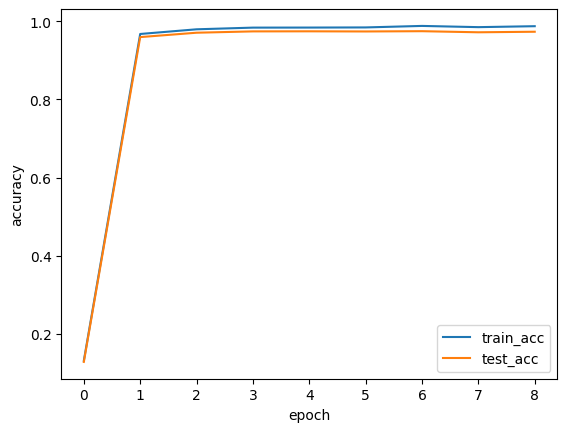

In [ ]:
plt.plot(train_acc_list)
plt.plot(test_acc_list)
plt.legend(['train_acc','test_acc'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

loss

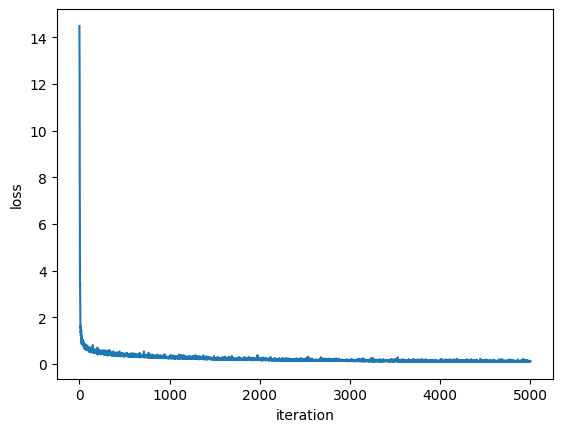

In [ ]:
plt.plot(train_loss_list)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.show()